In [2]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import tempfile
import gzip
import pylhe
import math
from scipy.optimize import curve_fit
from auxPlots import  xSecTest, getInfoSMS
from aux import getLHEevents, getDistributions, getInfo, getInfoSummary
from matplotlib.ticker import FixedLocator
from scipy import stats

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [3]:
#Reading files with bias
sm_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/*.npz'))
sm_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/*/*.npz'))
print(sm_files)
sm_qq_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/qq2ttbar_gs4/*.npz'))
data_sm_exp = []
data_qq_sm_exp = []
#Loading the distributions
for f in  sm_files:
    aux = np.load(f, allow_pickle = True)
    data_sm_exp.append(aux)
        
for f in  sm_qq_files:
    aux = np.load(f, allow_pickle = True)
    data_qq_sm_exp.append(aux)

data_sm_exp = sorted(data_sm_exp, key=lambda d: d['mass_params'][0])
print(data_sm_exp[0]['process'])

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_3/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_1/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_4/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_2/mPsiT_0_mSDM_0.npz']
$p p \to t \bar{t}$ 


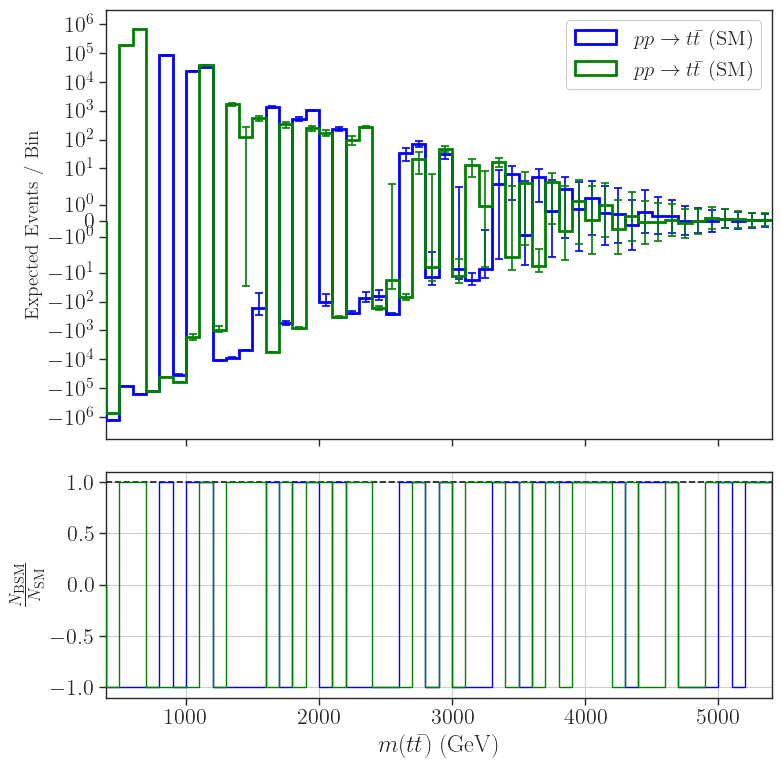

In [34]:
bins = np.arange(400., 5500., 100.)

################
# SM err (%)   #
################

lum = 500 # fb^-1

# -------------------------------------------------------------
# LUMINOSITY SCALING FACTOR
# Assuming your MC weights are in picobarns (pb), 1 pb = 1000 fb.
# If your weights are already in fb, change this to: lum_scale = lum
# -------------------------------------------------------------
lum_scale = lum * 1000.0 

sm_err = 0.05

x = (bins[:-1] + bins[1:]) / 2.0
bin_widths = np.diff(bins)
pmodels = []
bsm_colors = ['blue', 'green']
bsm_hists, bsm_errs, bsm_labels = [], [], []

# --- Setup and Binning ---
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize
                          =(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)
for j in range(0,len(data_sm_exp)-1,2):

    d = data_sm_exp[j]
    d_next = data_sm_exp[j+1]

    process = r'$p p \to t \bar{t}$'
    model = d['model']
    model_raw = d['model']
    model_name = str(np.atleast_1d(model_raw)[0])
    display_name = model_name
    pmodels.append(r'%s (%s)' % (process, display_name))
    label = pmodels[-1]


    h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

    h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
    hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
    

    # Scale by luminosity!
    h_bsm_total = (h1 - h2)  * lum_scale
    hErr_bsm_total_sq = (hErr1_sq + hErr2_sq + (sm_err*h1)**2 + (sm_err*h2)**2) * (lum_scale**2)

    integral_bsm = np.sum(h_bsm_total)
    h_bsm = h_bsm_total
    hErr_bsm = np.sqrt(hErr_bsm_total_sq)

    bsm_hists.append(h_bsm)
    bsm_errs.append(hErr_bsm)
    bsm_labels.append(label)

    axarr[0].hist(
        bins[:-1], weights=h_bsm, label=label, bins=bins,
        color=bsm_colors[int((j)/2)], alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )
    axarr[0].errorbar(
        x, h_bsm, yerr=np.sqrt(hErr_bsm), color=bsm_colors[int((j)/2)], 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )
    axarr[1].hist(
        bins[:-1], weights=np.abs(h_bsm)/h_bsm, label=label, bins=bins,
        color=bsm_colors[int((j)/2)], alpha=1.0, histtype='step', 
        linewidth=1, fill=False, zorder=3
    )
# Upper plot
axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
axarr[0].set_yscale('symlog')

# CHANGED Y-AXIS LABEL TO REFLECT EXPECTED EVENTS
axarr[0].set_ylabel(r'Expected Events / Bin', fontsize=14)
axarr[0].set_xlim(bins.min(), bins.max())

# Bottom plot
axarr[1].axhline(y=1, color='k', linestyle='--')
axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$')
axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
axarr[1].grid(True)
#axarr[1].set_yscale('symlog', linthresh=0.0001)
#axarr[1].set_ylim([-0.003, 0.3])

minor_tick_locations = np.concatenate((
    np.arange(-100.0, 0.0, 10.0), np.arange(-10.0, 1.0, 1.0), np.arange(0.0, 11.0, 1.0),
    np.arange(10.0, 100.0, 10.0), np.arange(100.0, 1100.0, 100.0), np.arange(1000.0, 4000.0, 1000.0)
))
axarr[1].yaxis.set_minor_locator(FixedLocator(minor_tick_locations))

plt.tight_layout()
#plt.savefig('Dists_comparison_interference.png')
plt.show()